# 06 — Partición, curva de aprendizaje y modelos base

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

Parte del conjunto depurado por `src/02_preprocesado.py` y de las once variables
seleccionadas en el apartado 4.5.

Objetivo: dividir los datos en entrenamiento y prueba, acreditar mediante una
curva de aprendizaje que el volumen de muestra es suficiente, y establecer el
rendimiento de referencia de tres modelos sin ajustar. Alimenta el apartado 4.6
de la memoria.

Se resuelve además con datos una decisión que quedó abierta en el análisis
exploratorio: si los híbridos enchufables deben entrar en el modelo principal
o analizarse por separado.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
LIMPIO = RAIZ / "datos" / "procesado" / "co2cars_2024_limpio.parquet"

SEMILLA = 42          # fija en todo el trabajo, para que los resultados se repitan
N_HILOS = 6           # 8 núcleos físicos disponibles; se dejan 2 libres
OBJETIVO = "Ewltp (g/km)"

NUMERICAS = ["M (kg)", "Ec (cm3)", "Ep (KW)", "Erwltp (g/km)",
             "cil_por_kw", "tiene_ecoinnov"]
CATEGORICAS = ["ft_norm", "Fm", "marca_norm", "MS", "Mp"]


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


MILES = FuncFormatter(lambda v, _: es(v))

df = pd.read_parquet(LIMPIO)
print(f"Conjunto depurado: {es(len(df))} registros")
print(df["regimen"].value_counts().to_string())

Conjunto depurado: 1.072.129 registros
regimen
Combustión            839684
Cero emisiones        155728
Híbrido enchufable     76717


## 1. Construcción de la matriz de variables

Las dos variables derivadas se recalculan aquí en lugar de leerlas de un fichero
intermedio, de modo que el cuaderno sea autónomo y la definición de cada una
quede a la vista.

In [2]:
def prepara(tabla):
    """Aplica la selección de variables del apartado 4.5 y devuelve X e y."""
    t = tabla.copy()
    t["cil_por_kw"] = t["Ec (cm3)"] / t["Ep (KW)"]
    t["tiene_ecoinnov"] = (t["Erwltp (g/km)"] > 0).astype(int)
    t = t.dropna(subset=[OBJETIVO])
    X = t[NUMERICAS + CATEGORICAS].copy()
    for c in CATEGORICAS:
        X[c] = X[c].astype("category")
    return X, t[OBJETIVO]


comb = df[df["regimen"] == "Combustión"]
X, y = prepara(comb)

print(f"Vehículos de combustión: {es(len(X))}")
print(f"Variables: {X.shape[1]} ({len(NUMERICAS)} numéricas, {len(CATEGORICAS)} categóricas)")
print("\nCardinalidad de las categóricas:")
for c in CATEGORICAS:
    print(f"  {c:<12} {X[c].nunique():>4} categorías")
print("\nValores ausentes por variable:")
print(X.isna().sum()[lambda s: s > 0].to_string() or "  ninguno")

Vehículos de combustión: 839.684
Variables: 11 (6 numéricas, 5 categóricas)

Cardinalidad de las categóricas:
  ft_norm         5 categorías
  Fm              4 categorías
  marca_norm    100 categorías
  MS             29 categorías
  Mp             12 categorías

Valores ausentes por variable:
M (kg)           1
Ec (cm3)         1
Ep (KW)       3212
cil_por_kw    3213


## 2. Partición en entrenamiento y prueba

Se reserva el 20 % de los datos para la evaluación final, estratificando por
tipo de combustible. Sin estratificar, categorías minoritarias como el E85
o el GLP podrían quedar mal representadas en uno de los dos conjuntos.

In [3]:
X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=X["ft_norm"])

print(f"Entrenamiento: {es(len(X_ent))} ({100*len(X_ent)/len(X):.1f} %)")
print(f"Prueba:        {es(len(X_pru))} ({100*len(X_pru)/len(X):.1f} %)")

reparto = pd.DataFrame({
    "entrenamiento": 100 * X_ent["ft_norm"].value_counts(normalize=True),
    "prueba":        100 * X_pru["ft_norm"].value_counts(normalize=True),
}).round(3)
print("\nReparto por combustible (%):")
print(reparto.to_string())

Entrenamiento: 671.747 (80.0 %)
Prueba:        167.937 (20.0 %)

Reparto por combustible (%):
         entrenamiento  prueba
ft_norm                       
petrol          76.563  76.564
diesel          19.238  19.239
lpg              3.834   3.834
e85              0.328   0.328
ng               0.036   0.036


## 3. Representatividad de la muestra frente a la población

La muestra del 10 % debe reproducir los estadísticos del conjunto completo. La
comparación se hace contra los agregados descargados del servidor de la Agencia,
que recorren los 10.782.314 registros.

In [4]:
poblacion = pd.read_csv(RAIZ / "datos" / "agregados" / "estadisticos_globales.csv")
p = poblacion.iloc[0]

muestra_total = df[df[OBJETIVO].notna()]
filas = [
    ["Emisiones medias (g/km)", p["CO2_medio_wltp"], muestra_total[OBJETIVO].mean()],
    ["Masa media (kg)",         p["Masa_media_kg"],  muestra_total["M (kg)"].mean()],
    ["Potencia media (kW)",     p["Potencia_media_kw"], muestra_total["Ep (KW)"].mean()],
    ["Cilindrada media (cm³)",  p["Cilindrada_media_cm3"], muestra_total["Ec (cm3)"].mean()],
]
rep = pd.DataFrame(filas, columns=["estadístico", "población", "muestra"])
rep["desviación %"] = (100 * (rep["muestra"] - rep["población"]) / rep["población"])

print(rep.round(3).to_string(index=False))
print("\nDesviación máxima:", f"{rep['desviación %'].abs().max():.3f} %")

            estadístico  población  muestra  desviación %
Emisiones medias (g/km)    106.792  106.679        -0.106
        Masa media (kg)   1558.774 1556.870        -0.122
    Potencia media (kW)    116.178  116.183         0.004
 Cilindrada media (cm³)   1545.891 1542.669        -0.208

Desviación máxima: 0.208 %


## 4. Curva de aprendizaje

Relaciona el volumen de datos de entrenamiento con el error obtenido. Si el
error se estabiliza a partir de cierto tamaño, queda acreditado que añadir más
observaciones no mejora la capacidad predictiva, y con ello que la muestra del
10 % era suficiente. Es la comprobación empírica de la decisión D-05, declarada
en el anteproyecto.

In [5]:
FRACCIONES = [0.02, 0.05, 0.10, 0.20, 0.35, 0.55, 0.75, 1.00]

def entrena_lgb(Xa, ya, semilla=SEMILLA, **kw):
    m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.08, num_leaves=63,
                          n_jobs=N_HILOS, random_state=semilla, verbose=-1, **kw)
    m.fit(Xa, ya, categorical_feature=CATEGORICAS)
    return m


curva = []
inicio = time.time()
for f in FRACCIONES:
    n = int(len(X_ent) * f)
    Xs = X_ent.sample(n, random_state=SEMILLA)
    ys = y_ent.loc[Xs.index]
    m = entrena_lgb(Xs, ys)
    curva.append({
        "fraccion": f,
        "n": n,
        "mae_ent": mean_absolute_error(ys, m.predict(Xs)),
        "mae_pru": mean_absolute_error(y_pru, m.predict(X_pru)),
    })
    print(f"  {f:>5.0%}  n = {es(n):>9}  MAE prueba = {curva[-1]['mae_pru']:.3f} g/km")

curva = pd.DataFrame(curva)
print(f"\nTiempo total: {time.time() - inicio:.0f} s")

     2%  n =    13.434  MAE prueba = 2.267 g/km


     5%  n =    33.587  MAE prueba = 1.994 g/km


    10%  n =    67.174  MAE prueba = 1.861 g/km


    20%  n =   134.349  MAE prueba = 1.787 g/km


    35%  n =   235.111  MAE prueba = 1.769 g/km


    55%  n =   369.460  MAE prueba = 1.752 g/km


    75%  n =   503.810  MAE prueba = 1.751 g/km


   100%  n =   671.747  MAE prueba = 1.735 g/km

Tiempo total: 36 s


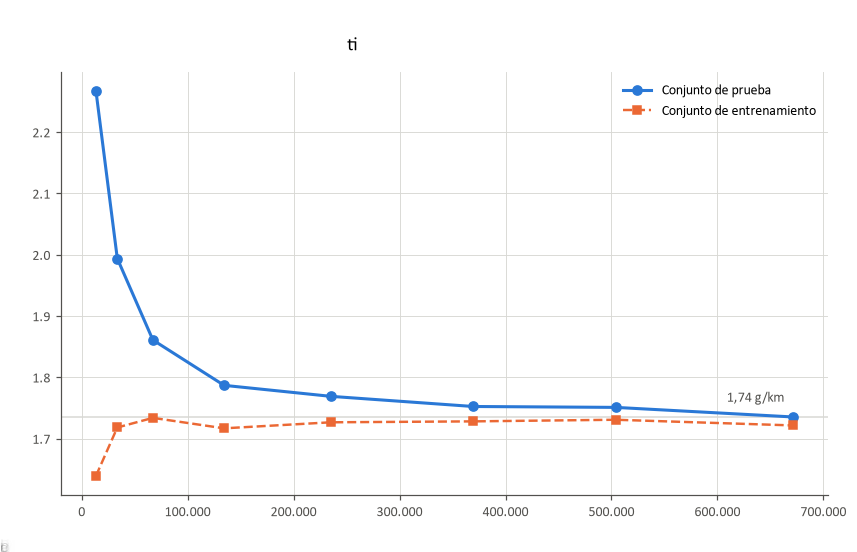

Mejora del MAE al pasar del 75 % al 100 % de los datos: 0.89 %


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curva["n"], curva["mae_pru"], marker="o", ms=6, lw=2,
        color=estilo.PALETA[0], label="Conjunto de prueba")
ax.plot(curva["n"], curva["mae_ent"], marker="s", ms=5, lw=1.6, ls="--",
        color=estilo.PALETA[1], label="Conjunto de entrenamiento")

# Referencia: el error alcanzado con el conjunto completo
final = curva["mae_pru"].iloc[-1]
ax.axhline(final, color=estilo.GRIS_REJILLA, lw=1, zorder=0)
ax.annotate(f"{es(final, 2)} g/km", (curva['n'].iloc[-1], final),
            textcoords="offset points", xytext=(-6, 10), ha="right",
            fontsize=9, color=estilo.GRIS_EJES)

ax.set_xlabel("Vehículos empleados en el entrenamiento")
ax.set_ylabel("Error absoluto medio (g/km)")
ax.xaxis.set_major_formatter(MILES)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Curva de aprendizaje\nLightGBM sobre vehículos de combustión, UE 2024",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_08_curva_aprendizaje.png")
plt.show()

mejora = 100 * (curva["mae_pru"].iloc[-2] - final) / curva["mae_pru"].iloc[-2]
print(f"Mejora del MAE al pasar del 75 % al 100 % de los datos: {mejora:.2f} %")

## 5. Modelos de referencia

Tres modelos sin ajuste de hiperparámetros, para fijar el punto de partida. La
regresión lineal exige codificación indicadora de las categóricas; los otros dos
las tratan de forma nativa. Las métricas son el error absoluto medio, que se lee
directamente en gramos por kilómetro, la raíz del error cuadrático medio, que
penaliza más los errores grandes, y el coeficiente de determinación.

In [7]:
def metricas(nombre, y_real, y_pred, segundos):
    return {"modelo": nombre,
            "MAE": mean_absolute_error(y_real, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
            "R2": r2_score(y_real, y_pred),
            "seg": round(segundos, 1)}


resultados = []

# --- Regresión lineal: referencia interpretable -----------------------
# Ni la regresión lineal ni Random Forest admiten variables categóricas, así
# que se codifican como indicadoras. Con marca y Estado de matriculación la
# matriz pasa de 11 a unas 180 columnas; se guarda en float32 para reducir a
# la mitad la memoria que ocupa.
t0 = time.time()
X_ent_oh = pd.get_dummies(X_ent, columns=CATEGORICAS, drop_first=True).astype("float32")
X_pru_oh = pd.get_dummies(X_pru, columns=CATEGORICAS, drop_first=True).astype("float32")
X_pru_oh = X_pru_oh.reindex(columns=X_ent_oh.columns, fill_value=0)
medias = X_ent_oh.mean()
X_ent_oh = X_ent_oh.fillna(medias)
X_pru_oh = X_pru_oh.fillna(medias)

lin = LinearRegression().fit(X_ent_oh, y_ent)
resultados.append(metricas("Regresión lineal", y_pru, lin.predict(X_pru_oh),
                           time.time() - t0))
print(f"  lineal        listo  ({X_ent_oh.shape[1]} columnas tras codificar)")

# --- Random Forest ----------------------------------------------------
# Los parámetros están dimensionados para el coste, no para el rendimiento:
# cada árbol se ajusta sobre el 30 % de las filas y la mitad de las columnas.
# Random Forest entra en la comparativa como referencia de método, mientras que
# el ajuste fino se reserva para el gradient boosting en el apartado siguiente.
t0 = time.time()
rf = RandomForestRegressor(n_estimators=80, min_samples_leaf=20,
                           max_samples=0.3, max_features=0.5,
                           n_jobs=N_HILOS, random_state=SEMILLA)
rf.fit(X_ent_oh, y_ent)
resultados.append(metricas("Random Forest", y_pru, rf.predict(X_pru_oh),
                           time.time() - t0))
print("  random forest listo")

# --- LightGBM ---------------------------------------------------------
t0 = time.time()
gbm = entrena_lgb(X_ent, y_ent)
resultados.append(metricas("LightGBM", y_pru, gbm.predict(X_pru), time.time() - t0))
print("  lightgbm      listo")

tabla = pd.DataFrame(resultados)
print("\n" + tabla.round(3).to_string(index=False))

  lineal        listo  (151 columnas tras codificar)


  random forest listo


  lightgbm      listo

          modelo   MAE   RMSE    R2  seg
Regresión lineal 7.281 10.222 0.871  4.3
   Random Forest 1.575  3.061 0.988 36.1
        LightGBM 1.740  2.743 0.991  4.7


## 6. ¿Deben entrar los híbridos enchufables en el modelo principal?

El análisis exploratorio mostró que la variable objetivo es una mezcla de
poblaciones separadas por un tramo vacío entre 50 y 85 g/km. La decisión de
segmentar se resuelve aquí de forma empírica: se entrena el mismo modelo sobre
los vehículos de combustión y sobre el conjunto ampliado con los enchufables, y
se comparan métricas y estructura de los residuos.

In [8]:
ampliado = df[df["regimen"].isin(["Combustión", "Híbrido enchufable"])]
Xa, ya = prepara(ampliado)
Xa_ent, Xa_pru, ya_ent, ya_pru = train_test_split(
    Xa, ya, test_size=0.20, random_state=SEMILLA, stratify=Xa["ft_norm"])

gbm_amp = entrena_lgb(Xa_ent, ya_ent)
pred_amp = gbm_amp.predict(Xa_pru)

comparacion = pd.DataFrame([
    metricas("Solo combustión", y_pru, gbm.predict(X_pru), 0),
    metricas("Combustión + enchufables", ya_pru, pred_amp, 0),
]).drop(columns="seg")
print(comparacion.round(3).to_string(index=False))
print("\nLas métricas del modelo ampliado no son directamente comparables:")
print("opera sobre un rango de valores mayor, lo que infla el R² por construcción.")

                  modelo   MAE  RMSE    R2
         Solo combustión 1.740 2.743 0.991
Combustión + enchufables 1.788 3.031 0.994

Las métricas del modelo ampliado no son directamente comparables:
opera sobre un rango de valores mayor, lo que infla el R² por construcción.


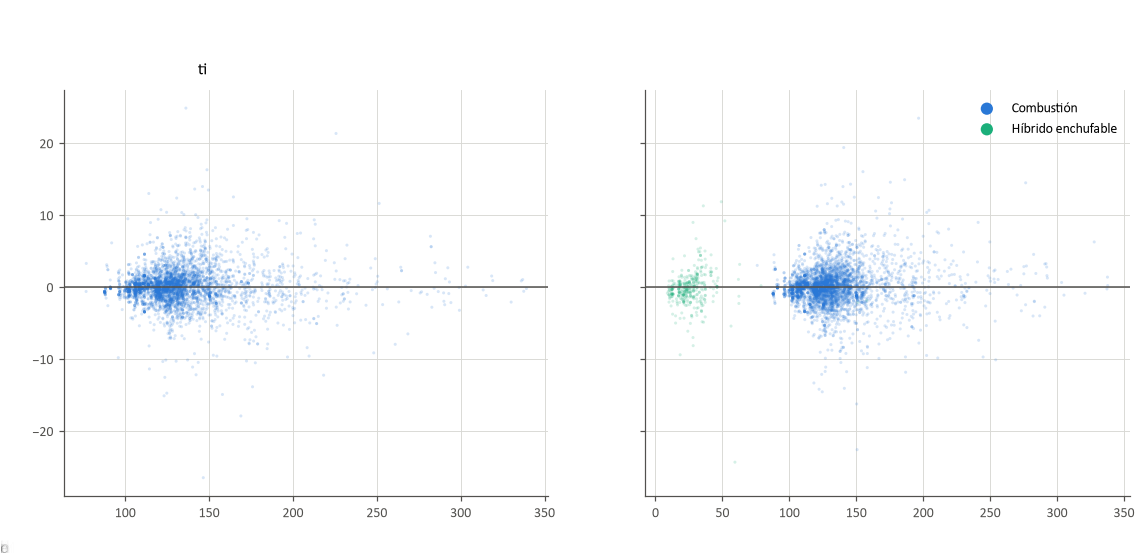

Error absoluto medio por régimen en el modelo ampliado:
  Combustión             MAE =  1.800 g/km   (n = 167.937)
  Híbrido enchufable     MAE =  1.661 g/km   (n = 15.344)


In [9]:
# La comparación decisiva no está en las métricas sino en los residuos. Si el
# modelo ampliado acierta bien dentro de cada grupo pero muestra sesgo entre
# ellos, la mezcla de poblaciones estará contaminando el ajuste.
res_amp = ya_pru - pred_amp
reg_pru = ampliado.loc[Xa_pru.index, "regimen"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

ax1.scatter(gbm.predict(X_pru)[::40], (y_pru - gbm.predict(X_pru))[::40],
            s=4, alpha=0.18, color=estilo.PALETA[0], edgecolor="none")
ax1.axhline(0, color=estilo.GRIS_EJES, lw=1)
ax1.set_title("Modelo de combustión", fontsize=11, pad=10, loc="left")
ax1.set_xlabel("Predicción (g/km)")
ax1.set_ylabel("Residuo (g/km)")

COLOR_REG = {"Combustión": estilo.PALETA[0], "Híbrido enchufable": estilo.PALETA[2]}
for r, col in COLOR_REG.items():
    m = (reg_pru == r).values
    ax2.scatter(pred_amp[m][::40], res_amp[m][::40], s=4, alpha=0.18,
                color=col, edgecolor="none", label=r)
ax2.axhline(0, color=estilo.GRIS_EJES, lw=1)
ax2.set_title("Modelo ampliado con enchufables", fontsize=11, pad=10, loc="left")
ax2.set_xlabel("Predicción (g/km)")
leg = ax2.legend(frameon=False, fontsize=9, markerscale=4)
for h in leg.legend_handles:
    h.set_alpha(1)

fig.suptitle("Residuos frente a predicción en el conjunto de prueba",
             fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_09_residuos.png")
plt.show()

print("Error absoluto medio por régimen en el modelo ampliado:")
for r in ["Combustión", "Híbrido enchufable"]:
    m = (reg_pru == r).values
    print(f"  {r:<22} MAE = {mean_absolute_error(ya_pru[m], pred_amp[m]):6.3f} g/km"
          f"   (n = {es(m.sum())})")

## 7. ¿Física o identificación?

El error obtenido equivale al 1,4 % de la mediana de la variable objetivo, un
resultado muy bajo para once variables. Cabe la sospecha de que el modelo no
esté aprendiendo la relación entre las características del vehículo y sus
emisiones, sino identificando configuraciones concretas: con más de ochocientos
mil registros, muchas combinaciones de marca, motorización y país se repiten
miles de veces, y memorizar el valor asociado a cada una es más sencillo que
aprender la física subyacente.

La comprobación consiste en retirar progresivamente las variables de identidad
comercial y geográfica. Si el error se mantiene, el modelo describe una relación
física; si se dispara, estaba reconociendo vehículos.

In [10]:
def entrena(Xa, ya, cats, semilla=SEMILLA):
    """LightGBM con la lista de categóricas que reciba, para poder retirarlas."""
    m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.08, num_leaves=63,
                          n_jobs=N_HILOS, random_state=semilla, verbose=-1)
    m.fit(Xa, ya, categorical_feature=cats if cats else "auto")
    return m


CONJUNTOS = {
    "Solo físicas":                 (NUMERICAS, []),
    "Físicas + tecnología":         (NUMERICAS + ["ft_norm", "Fm"], ["ft_norm", "Fm"]),
    "Físicas + tecnología + país":  (NUMERICAS + ["ft_norm", "Fm", "MS"], ["ft_norm", "Fm", "MS"]),
    "Todas":                        (NUMERICAS + CATEGORICAS, CATEGORICAS),
}

ablacion = []
for nombre, (cols, cats) in CONJUNTOS.items():
    t0 = time.time()
    m = entrena(X_ent[cols], y_ent, cats)
    r = metricas(nombre, y_pru, m.predict(X_pru[cols]), time.time() - t0)
    r["variables"] = len(cols)
    ablacion.append(r)
    print(f"  {nombre:<30} MAE = {r['MAE']:.3f}")

ablacion = pd.DataFrame(ablacion)[["modelo", "variables", "MAE", "RMSE", "R2"]]
print("\n" + ablacion.round(3).to_string(index=False))

base = ablacion.loc[ablacion.modelo == "Solo físicas", "MAE"].iloc[0]
full = ablacion.loc[ablacion.modelo == "Todas", "MAE"].iloc[0]
print(f"\nAl retirar marca, agrupación y país el error pasa de {full:.3f} "
      f"a {base:.3f} g/km, un {100*(base-full)/full:.1f} % más.")

  Solo físicas                   MAE = 2.112


  Físicas + tecnología           MAE = 1.983


  Físicas + tecnología + país    MAE = 1.978


  Todas                          MAE = 1.740

                     modelo  variables   MAE  RMSE    R2
               Solo físicas          6 2.112 3.477 0.985
       Físicas + tecnología          8 1.983 3.277 0.987
Físicas + tecnología + país          9 1.978 3.089 0.988
                      Todas         11 1.740 2.743 0.991

Al retirar marca, agrupación y país el error pasa de 1.740 a 2.112 g/km, un 21.4 % más.


## 8. Importancia de las variables

Reparto de las divisiones del modelo entre las variables disponibles. Es una
primera aproximación que se completará en el apartado 4.8 con el análisis de
interpretabilidad, que sí atribuye contribuciones al valor predicho.

      variable   pct
       Ep_(KW) 63.25
        M_(kg) 13.33
    marca_norm  7.40
            Fm  6.47
      Ec_(cm3)  6.21
 Erwltp_(g/km)  0.97
    cil_por_kw  0.93
       ft_norm  0.83
            Mp  0.34
            MS  0.26
tiene_ecoinnov  0.00


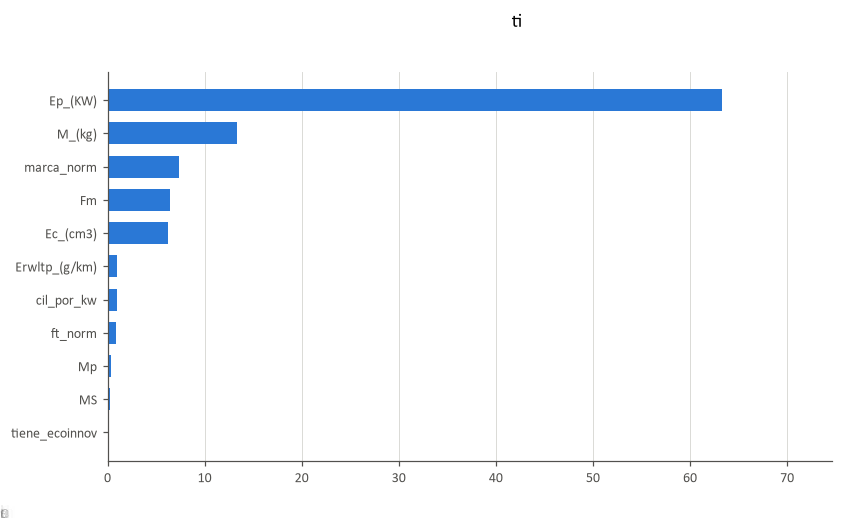

In [11]:
imp = (pd.DataFrame({"variable": gbm.feature_name_,
                     "peso": gbm.booster_.feature_importance(importance_type="gain")})
       .sort_values("peso", ascending=False))
imp["pct"] = 100 * imp["peso"] / imp["peso"].sum()

print(imp[["variable", "pct"]].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
top = imp.head(11).iloc[::-1]
ax.barh(range(len(top)), top["pct"], color=estilo.PALETA[0], height=0.66)
for i, v in enumerate(top["pct"]):
    ax.text(v + 0.6, i, f"{es(v, 1)} %", va="center", fontsize=8.5,
            color=estilo.GRIS_EJES)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["variable"], fontsize=9)
ax.set_xlabel("Contribución a la reducción del error (%)")
ax.set_xlim(0, max(top["pct"]) * 1.18)
ax.grid(axis="y", visible=False)
ax.set_title("Importancia de las variables en el modelo de combustión\n"
             "LightGBM sin ajuste de hiperparámetros",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_10_importancia.png")
plt.show()